# Auto BC Processing

__Contributors:__ Curtis Smith, Marissela Gomez (marissela.gomez@stantec.com)  
__Last updated:__ 2/4/2026  

__Notebook Description:__  
- Loads the hdf file results from the HEC-RAS draft model hdf output file
- gathers model data and other input data (flow change locations)  
- writes BC conditions (internal and external)
- connects dss file data to internal and external boundary condition per event

__Inputs:__ 
- json files with dictionaries for feature connectivity  
- draft models for working model and direct upstream model  
- HMS data in the format of geodatabases, dss files and geojsons  

__Outputs:__
- project files for hec-ras, including plan and unsteady flow data.
- dss files connecting to unsteady flow data

__User QC of output after the notebook is done running:__  
- review that all expected events are in the model as dss files 


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#imports
import os
import pathlib as pl

## Set directories and user defined variables

In [3]:
# Set working directory and folder variables
# one folder up from current working directory should have a folder with the following structure: 
# src/inputs_files 
# with all the .py input files for each notebook present.
os.chdir('..')
home = pl.Path(os.getcwd())

print('home is at ',home)
assert home.stem == 'hms_to_ras_sst', 'Please restart the kernal'

# Import the input file and functions created for this notebook
from src.inputs_py_files.auto_bc_creation_inputs import * #This notebook also creates the required folders if they do not exist
from src.hdf import *

home is at  C:\_code\hms_to_ras_sst


In [4]:
#hdf version check
print(h5py.__version__)# Make sure the version is 2.9 or above

3.8.0


In [5]:
#hard variables for project
model_name = f'{model_prefix}{huc}' #folder within inputs folder
huc_map = {}
start_id = 51 #starting number for added files related to events

## Get Relevant RAS Files

In [6]:
plan_path, in_geom_path, in_flow_path = get_current_ras_files(models_folder/huc/f'{model_name}.prj')

## Copy HDF File to output folder for reading

In [7]:
# reset hdf file
geo_out_hdf = shutil.copy(models_folder/huc/f'{model_name}{in_geom_path.suffix}.hdf',outputs/f'{model_name}.g{start_id}.hdf')
geo_out = shutil.copy(models_folder/huc/f'{model_name}{in_geom_path.suffix}',outputs/f'{model_name}.g{start_id}')

## Update Geometry file and HDF Files to include Flow Change locations

In [8]:
#geo hdf
hf_geo = h5py.File(str(geo_out_hdf),'r')

#get domain names
domain_geo = str(list(hf_geo['Geometry']['2D Flow Areas']['Attributes'])[0][0]).strip("'b\'")

#get global projection for all geometric operations. Assume the same between model plans
crs_prj = str(hf_geo.attrs['Projection']).strip("'b\'")

## Load geom hdf data into a geo dataframe

### External BCs

In [9]:
#get downstream domain
geo = gpd.GeoSeries(geometry.Polygon(map(geometry.Point, hf_geo['Geometry']['2D Flow Areas']['Polygon Points'][:]))) 
ds_area = gpd.GeoDataFrame({'name':domain_geo,'geometry':geo}, crs=crs_prj)

In [10]:
#get model information from json files related to its internal bc connections and external connections with other models. 
with open(inputs/project/'dictionaries'/'HUC10_outflow_toHUC10.json') as src:
    huc_connect_huc = json.load(src)
with open(inputs/project/'dictionaries'/'HUC10_into_dsJunction.json') as src:
    huc_connect_j = json.load(src)
with open(inputs/project/'dictionaries'/'HUC10_Junctions.json') as src:
    huc_js = json.load(src)
with open(inputs/project/'dictionaries'/'source_if_reservoir.json') as src:
    src_js = json.load(src)
with open(inputs/project/'dictionaries'/'hms_feature_origin_dict.json') as src:
    src_huc_hms = json.load(src)
with open(inputs/project/'dictionaries'/'outofscope_HUC10_to_HUC10.json') as src:
    out_of_scope_huc_inflows = json.load(src)
with open(inputs/project/'dictionaries'/'junc_res_sink_next_junc_down.json') as src:
    jrs_next_junc = json.load(src)
######################################################
#This dictionary will contain information related to all the events that will be run in each model.
with open(inputs/project/'dictionaries'/'event_tie_ins'/'all_model_rec_events.json') as src:
    all_rec_events = json.load(src)


In [11]:
#get upstream hucs list
us_hucs = []
us_j = []
for key, val in huc_connect_huc.items():
    if val == huc:
        us_hucs.append(key)
        us_j.append(huc_connect_j[key])

In [12]:
print(f'upstream models required are {us_hucs}') 
#This is the list of IN SCOPE upstream models from which we need to bring in the external boundary condition

upstream models required are ['1008001202', '1008001303']


In [13]:
#get external boundary conditions from upstream models as inflow bcs
for us_huc in us_hucs:
    us_model_name = f'{model_prefix}{us_huc}' #folder within inputs folder
    assert os.path.exists(models_folder/us_huc/f'{us_model_name}.prj'), f'Upstream model {us_model_name} needs to be added to the input project folder at {models_folder/us_huc}'
    us_plan_path, us_in_geom_path, us_in_flow_path = get_current_ras_files(models_folder/us_huc/f'{us_model_name}.prj')

    #get current geometry
    inflow_bc = get_ext_bc_lines(ds_area,f'{us_plan_path}.hdf',bc_line_offset=400)
    
    #add junction name
    inflow_bc['junction'] = us_j[us_hucs.index(us_huc)]
    
    #add slope from input flow file. may want to replace with actual EG from model
    with open (us_in_flow_path,'r') as flow_file:
        content = flow_file.read()
    for bc_name in inflow_bc.name.to_list():
        slope = re.search(f'{bc_name}[\w\W]*Friction Slope=0.\d*',content).group(0).split('=')[-1]
    inflow_bc['slope'] = slope
    
    #concat gdfs if needed
    if us_hucs.index(us_huc) == 0:
        inflow_bcs = inflow_bc
    else:
        inflow_bcs = pd.concat([inflow_bcs,inflow_bc])
if us_hucs:
    inflow_bcs.reset_index(inplace=True,drop=True)
else:
    inflow_bcs = pd.DataFrame(columns=['empty'])

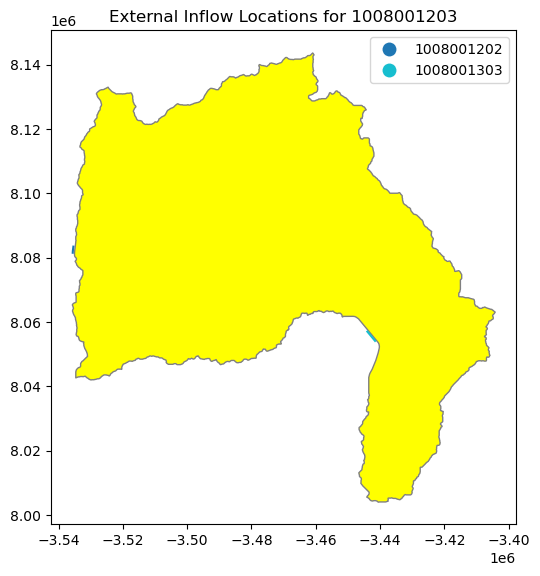

In [14]:
#plot to confirm areas
if not inflow_bcs.empty:
    fig , ax = plt.subplots(figsize=(6,10))
    ds_area.plot(ax = ax, color='yellow', edgecolor='gray')
    inflow_bcs.plot(ax = ax, column='huc',legend=True)
    ax.set_title(f'External Inflow Locations for {huc}')
    plt.savefig(plots/f'{huc}_ext.png')
else:
    print('no upstream model inflows into this huc')

In [15]:
#save to file
if not inflow_bcs.empty:
    inflow_bcs[['name','huc','geometry','junction','slope']].to_file(f'{outputs}/{huc}_ext_forcing_bc_lines.shp')
    #create dictionary for ras dev
    ext_bc_dict = inflow_bcs.to_dict()
    ext_index = inflow_bcs.index.tolist()
else:
    #create empty values
    ext_bc_dict = {}
    ext_index = []
ext_bc_dict['in_flow_path'] = in_flow_path
ext_bc_dict['in_plan_path'] = plan_path

### External BCs for Out of Scope HUCs

This portion of the code will tie in a hydrograph at an external boundary condition related to an out of scope model. 
The requirement for this portion is that the current model contains a boundary condition at the site of connection with the out of scope model 
(if they are an inflow). 
The naming convention should be "inflow_from_{out of scope model name}". This should match exactly what is listed in the dictionary.

In [16]:
#get any out of scope huc inflows
us_oos_hucs = []
us_oos_j = []
for k,v in out_of_scope_huc_inflows.items():
    if v == huc:
        us_oos_hucs.append(k)

for oos_huc in us_oos_hucs:
    us_oos_j.append(huc_connect_j[oos_huc])
if us_oos_hucs:
    print(f'adding additional unscoped upstream models {us_oos_hucs}')
else:
    print('no additional unscoped upstream models to add')

no additional unscoped upstream models to add


In [17]:
#get current geometry
for inflow_huc in us_oos_hucs:
    inflow_bc_oos = get_int_bc_lines(geo_out_hdf,inflow_huc)
    
    #add junction name
    inflow_bc_oos['junction'] = us_oos_j[us_oos_hucs.index(inflow_huc)]
    
    #add slope from input flow file. may want to replace with actual EG from model
    with open (in_flow_path,'r') as flow_file:
        content = flow_file.read()
    for bc_name in inflow_bc_oos.name.to_list():
        slope = re.search(f'{bc_name}[\w\W]*Friction Slope=0.\d*',content).group(0).split('=')[-1]
    inflow_bc_oos['slope'] = slope
    
    #concat gdfs if needed
    if us_oos_hucs.index(inflow_huc) == 0:
        inflow_bcs_oos = inflow_bc_oos
    else:
        inflow_bcs_oos = pd.concat([inflow_bcs_oos,inflow_bc_oos])
if us_oos_hucs:
    inflow_bcs_oos.reset_index(inplace=True,drop=True)
else:
    inflow_bcs_oos = pd.DataFrame(columns=['empty'])

In [18]:
#plot to confirm areas
if not inflow_bcs_oos.empty:
    fig , ax = plt.subplots(figsize=(6,10))
    inflow_bcs_oos.plot(ax = ax, column='huc',legend=True)
    ds_area.plot(ax = ax, color='yellow')
    ax.set_title(f'External Inflow Locations for Out of Scope HUC {huc}')
    plt.savefig(plots/f'{huc}_ext.png')
else:
    print('no inflows into this huc')

no inflows into this huc


In [19]:
#save to file
if not inflow_bcs_oos.empty:
    inflow_bcs_oos[['name','huc','geometry','junction','slope']].to_file(f'{outputs}/{huc}_ext_forcing_bc_lines_oos.shp')
    #create dictionary for ras dev
    ext_bc_dict_oos = inflow_bcs_oos.to_dict()
    ext_index_oos = inflow_bcs_oos.index.tolist()
    inflow_bcs_combined = pd.concat([inflow_bcs, inflow_bcs_oos])
    inflow_bcs_combined.reset_index(inplace=True,drop=True)
    ext_bc_dict_combined = inflow_bcs_combined.to_dict()
    ext_index_combined = inflow_bcs_combined.index.tolist()
else:
    #create empty values
    ext_bc_dict_oos = {}
    ext_index_oos = []
    ext_bc_dict_combined = ext_bc_dict
    ext_index_combined = ext_index
ext_bc_dict_combined['in_flow_path'] = in_flow_path
ext_bc_dict_combined['in_plan_path'] = plan_path

### Internal BCs - INFLOW

In [20]:
#### Get HMS Data ####
#get events for each recurrence interval from output data. This code should've been run in prior notebook and will now be read from a json
events_dict = dict()
events_dict[huc] = all_rec_events[huc]

In [21]:
# Import schematic data
huc8_gdb = glob.glob(str(inputs/project/'schematics'/schematic_input_type), recursive=False)
# print('Identified inputs:',huc8_gdb)
junctions = locate_string_gdb_to_concat_gdf(huc8_gdb,'Junction')
if 'geometry' in junctions.columns.to_list():
    junctions = junctions.set_geometry('geometry')
sinks = locate_string_gdb_to_concat_gdf(huc8_gdb,'Sink')
if 'geometry' in sinks.columns.to_list():
    sinks = sinks.set_geometry('geometry')
subbasins = locate_string_gdb_to_concat_gdf(huc8_gdb,'Subbasin')
if 'geometry' in subbasins.columns.to_list():
    subbasins = subbasins.set_geometry('geometry')
reaches = locate_string_gdb_to_concat_gdf(huc8_gdb,'Reach')
if 'geometry' in reaches.columns.to_list():
    reaches = reaches.set_geometry('geometry')
    og_r_quantity = len(reaches)
    #explode multi-part reaches to avoid reaching multilinestring from geodatabases. Ensure that additional reaches are not created in the process.
    reaches = reaches.explode(index_parts=True)
    assert og_r_quantity == len(reaches), 'Review why the number of reaches changed after exploding multi-part geometries.'

reservoirs = locate_string_gdb_to_concat_gdf(huc8_gdb,'Reservoir',coordinate_sys=junctions.crs)
if 'geometry' in reservoirs.columns.to_list():
    reservoirs = reservoirs.to_crs(junctions.crs).set_geometry('geometry')

assert junctions.crs == sinks.crs == subbasins.crs == reaches.crs == reservoirs.crs, 'Review why the projections of each gdf are not the same.'

After searching through 15 geodatabases/geopackages, there are now 4378 "Junction" features
After searching through 15 geodatabases/geopackages, there are now 16 "Sink" features
After searching through 15 geodatabases/geopackages, there are now 6965 "Subbasin" features
After searching through 15 geodatabases/geopackages, there are now 4378 "Reach" features


C:\Users\magomez\.conda\envs\regularhome\lib\site-packages\geopandas\array.py:1406: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as USA_Contiguous_Albers_Equal_Area_Conic_USGS_version (the single non-null crs provided).
  warnings.warn(


After searching through 15 geodatabases/geopackages, there are now 1 "Reservoir" features


In [23]:
#combine geodatagrames into hms_points
hms_points = pd.concat([junctions,reservoirs,sinks]).set_index('name')

In [24]:
##filter to relevant HUC 10
junctions_s_r = hms_points.loc[hms_points.index.isin(huc_js[huc])]

In [25]:
#get external bcs to exclude from internal bc process
if us_hucs:
    #add upstream hucs
    ext_bc_h = list(ext_bc_dict['huc'].values())
    #add out of scope upstream hucs
    if ext_bc_dict_oos:
        for oos_huc in ext_bc_dict_oos['huc'].values():
            ext_bc_h.append(oos_huc)
    #add current huc
    ext_bc_h.append(huc)
    ext_bc_j = []
    #exclude any inflows and outflow points to huc
    for h in ext_bc_h:
        ext_bc_j.append(huc_connect_j[h])
else:
    ext_bc_j = [huc_connect_j[huc]]

In [26]:
#remove any inflow points that are already included as an external boundary condition
int_bcs = junctions_s_r.copy().loc[junctions_s_r.index.isin(ext_bc_j) == False]

In [27]:
####modify to make useful for bc purposes###
#to be consistent with ext code
int_bcs['junction'] = int_bcs.index
#Internal BC EG slope should only impact the normal depth calc used to distribute flow to adjacent cells. 
#Assume uniform value of 0.01 (relatively steep) to force flow to the low point of the cell
int_bcs['slope'] = 0.01

In [28]:
#remove any inflow points that don't have contributing subbasin flows
with open(inputs/project/'dictionaries'/'Junction_Subbasins.json') as src:
    j_connect_sub = json.load(src)

int_bcs['has_contrib_sbs'] = int_bcs['junction'].apply(lambda x: True if j_connect_sub[x] else False)
int_bcs = int_bcs.copy().loc[int_bcs['has_contrib_sbs'] == True]
print('original length of the list of internal bcs',len(int_bcs))

original length of the list of internal bcs 82


In [29]:
#filter from the variable any sinks that are directly upstream of an assigned ds junction. 
#if the node is kept, then that introduced flow at this point would be counted twice within the flow path.
remove_node = [i for i,j in jrs_next_junc.items() if j == huc_connect_j[huc] and re.search('sink', i, re.IGNORECASE)]
print('The following node be excluded from the model due to being a sink directly upstream of the assigned downstream boundary condition of the model', remove_node)

int_bcs = int_bcs.copy().loc[~int_bcs['junction'].isin(remove_node)]
print('new length of the list of internal bcs',len(int_bcs))

The following node be excluded from the model due to being a sink directly upstream of the assigned downstream boundary condition of the model ['HUC_012_Sink_0']
new length of the list of internal bcs 81


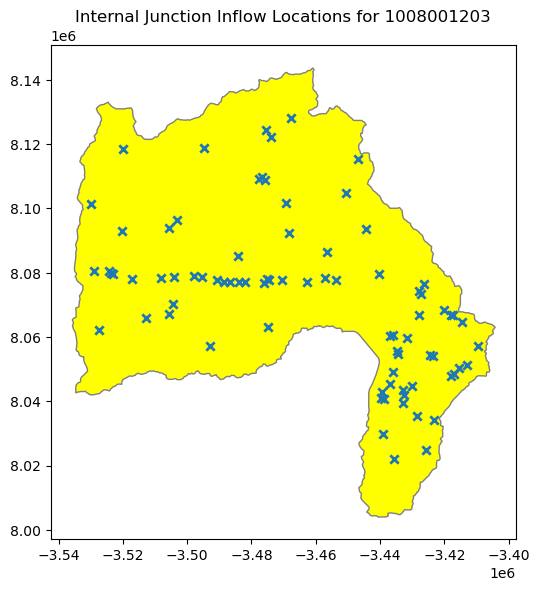

In [30]:
#plot to confirm areas
fig , ax = plt.subplots(figsize=(6,10))
ds_area.plot(ax = ax, color='yellow', edgecolor='gray')
int_bcs.plot(ax=ax,linewidth=2,marker='x')
ax.set_title(f'Internal Junction Inflow Locations for {huc}')
plt.savefig(plots/f'{huc}_int.png')

In [31]:
#turn points into lines
int_bcs['geometry'] = int_bcs['geometry'].apply(lambda mid: LineString([Point(mid.x-1, mid.y-1),Point(mid.x+1, mid.y+1)]))
int_bcs.reset_index(inplace=True)

In [32]:
if not int_bcs.empty:
    int_bcs[['geometry','junction','slope']].to_file(f'{outputs}/{huc}_in_forcing_bc_lines.shp')

In [33]:
int_bc_dict = int_bcs.to_dict()
int_index = int_bcs.index.tolist()
int_bc_dict['in_flow_path'] = in_flow_path
int_bc_dict['in_plan_path'] = plan_path

In [34]:
hf_geo.close()

### Internal BCs - FLOW REDUCTIONS

In [35]:
#get reach junction dictionary
with open(inputs/project/'dictionaries'/'reachfromjunction.json') as src:
    reach_to_us_junction = json.load(src)

In [36]:
##filter to relevant flow reduction reaches
reaches_col = reaches.columns.to_list()
if 'Channel_Loss' in reaches_col:
    cl = 'Channel_Loss'
    sb = 'Channel_Loss_Flow_Rate'
    rd = 'Channel_Loss_Fraction'
else:
    print('Major field missing from the reaches file. Please resolve before continuing.')

#filter by reaches with flow reduction
reaches_r = reaches.loc[(reaches[rd] != '0') | (reaches[sb] != '0')]

#channel 2 is initial flow reduction, channel 3 is % reduction of flow hydrograph so adjusted flow hydrograph = (inflow - 5) *.8
#filter by relevant huc
ds = 'Downstream'
reaches_r_s = reaches_r.copy().loc[reaches_r[ds].isin(huc_js[huc]) == True]

In [37]:
#flow reduction reaches that will be added to the model
reaches_r_s

,,name,Description,Last_Modified_Date,Last_Modified_Time,Latitude_Degrees,Longitude_Degrees,Canvas_X,Canvas_Y,From_Canvas_X,From_Canvas_Y,...,Index_Flow,Maximum_Depth_Iterations,Maximum_Route_Step_Iterations,Channel_Loss,Channel_Loss_Flow_Rate,Channel_Loss_Fraction,End_Channel_Loss,Source_Path,Number_Subreaches,geometry
3542,0,HUC_013_R_80,river station: 10713.46,21 March 2025,13:57:17,44.35968006502631,-109.19881674160425,-3428637.0493903286,8035311.010402821,-3435737.0493903286,8022011.010402821,...,500,20,30,Constant,5,0.2,,HUC_10080013_SST.gdb,NaN,"LINESTRING (-3428637.049 8035311.010, -3428537..."
3575,0,HUC_013_R_114,river station: 2364.31,21 March 2025,13:57:17,44.43774650545943,-109.22926705572115,-3435857.0042414865,8060547.617532072,-3434837.0493903104,8055611.010402844,...,500,20,30,Constant,5,0.2,,HUC_10080013_SST.gdb,NaN,"LINESTRING (-3435857.004 8060547.618, -3435337..."


In [38]:
#Prepare the reaches for introduction into the model.
if not reaches_r_s.empty:
    reaches_r_s['subtraction'] = reaches_r_s[sb]
    reaches_r_s['reduction'] = reaches_r_s[rd]
else:
    reaches_r_s['subtraction'] = 0
    reaches_r_s['reduction'] = 0
    
reaches_r_s['upstream'] = reaches_r_s['name'].apply(lambda x: reach_to_us_junction[x])

####modify to make useful for bc purposes###
#to be consistent with ext code
reaches_r_s['junction'] = reaches_r_s.name
#Internal BC EG slope should only impact the normal depth calc used to distribute flow to adjacent cells. 
#Assume uniform value of 0.01 (relatively steep) to force flow to the low point of the cell
reaches_r_s['slope'] = 0.01

reaches_r_s.reset_index(inplace=True)
#Export a shapefile for future reference of flow reduction presence and locations.
if not reaches_r_s.empty:
    reaches_r_s[['geometry','junction','slope']].to_file(f'{outputs}/{huc}_flow_reduction_forcing_bc_lines.shp')

int_r_bc_dict = reaches_r_s.to_dict()
int_r_index = reaches_r_s.index.tolist()
int_r_bc_dict['in_flow_path'] = in_flow_path
int_r_bc_dict['in_plan_path'] = plan_path

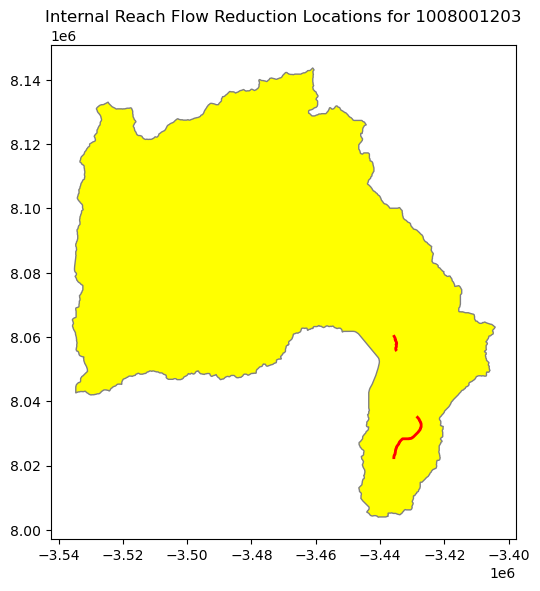

In [39]:
#plot to confirm areas
fig , ax = plt.subplots(figsize=(6,10))
ds_area.plot(ax = ax, color='yellow', edgecolor='gray')
reaches_r_s.plot(ax=ax,linewidth=2,color='red')
ax.set_title(f'Internal Reach Flow Reduction Locations for {huc}')
plt.savefig(plots/f'{huc}_int.png')

In [40]:
hf_geo.close()

### Internal BCs - MAJOR SOURCE ADD INS

In [41]:
#get sources from provided schematics
sources = locate_string_gdb_to_concat_gdf(huc8_gdb,'Source')
if 'geometry' in sources.columns.to_list():
    sources = sources.set_geometry('geometry')

After searching through 15 geodatabases/geopackages, there are now 18 "Source" features


In [42]:
#pull out only the inflows that are tagged as reservoirs
src_inflows = {}
for key, value in src_js.items():
    if 'TRUE' in value:
        src_inflows[key] = value['TRUE']
#get hms schematic information for sources
hms_points = sources.set_index('name')

#filter to relevant HUC 10
hms_points['in_huc'] = hms_points.within(ds_area.iloc[0].geometry)
junctions_s_r = hms_points.loc[hms_points['in_huc'] == True]
#filter only new sources of flow from dam operations
src_bcs = junctions_s_r.copy().loc[junctions_s_r.index.isin(list(src_inflows.keys())) == True]

In [43]:
#to be consistent with ext code
src_bcs['junction'] = src_bcs.index
#Internal BC EG slope should only impact the normal depth calc used to distribute flow to adjacent cells. 
#Assume uniform value of 0.01 (relatively steep) to force flow to the low point of the cell
src_bcs['slope'] = 0.01

if not src_bcs.empty:

    #update geometry based on dictionary
    src_bcs['geometry'] = src_bcs.apply(lambda x: Point(src_inflows[x.junction]),axis=1)
else:
    pass

C:\Users\magomez\.conda\envs\regularhome\lib\site-packages\geopandas\plotting.py:693: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  warnings.warn(


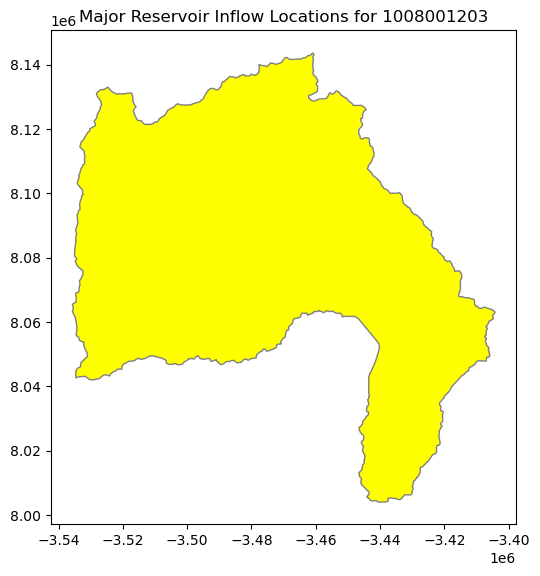

In [44]:
#plot to confirm areas
fig , ax = plt.subplots(figsize=(6,10))
ds_area.plot(ax = ax, color='yellow', edgecolor='gray')
src_bcs.plot(ax=ax,linewidth=2,marker='o')
ax.set_title(f'Major Reservoir Inflow Locations for {huc}')
plt.savefig(plots/f'{huc}_int.png')

In [45]:
#turn points into lines
src_bcs['geometry'] = src_bcs['geometry'].apply(lambda mid: LineString([Point(mid.x-1, mid.y-1),Point(mid.x+1, mid.y+1)]))

In [46]:
src_bcs.reset_index(inplace=True)

In [47]:
src_bcs

,name,Last_Modified_Date,Last_Modified_Time,Canvas_X,Canvas_Y,From_Canvas_X,From_Canvas_Y,Downstream,Flow_Method,Flow_Gage,End_Flow_Method,geometry,Source_Path,Area,in_huc,junction,slope


In [48]:
#Export a shapefile for future reference of locations where flow from a source was introduced. 
if not src_bcs.empty:
    src_bcs[['geometry','junction','slope']].to_file(f'{outputs}/{huc}_in_forcing_bc_lines_sources.shp')

In [49]:
src_bc_dict = src_bcs.to_dict()
src_index = src_bcs.index.tolist()
src_bc_dict['in_flow_path'] = in_flow_path
src_bc_dict['in_plan_path'] = plan_path

In [50]:
hf_geo.close()

## Update geometry with US external boundary conditions

### Write to geometry text file as new BC Line and breakline

In [51]:
#need to update breakline option to write with the actual perimeter to avoid cell errors.
add_inflow_bcs(in_geom_path,ext_index,ext_bc_dict,domain_geo, geo_out)

In [52]:
#need to update breakline option to write with the actual perimeter to avoid cell errors.
update_oos_bcs(geo_out,ext_index_oos,ext_bc_dict_oos,domain_geo, geo_out)

In [53]:
#need to update to write with the actual perimeter to avoid cell errors.
add_inflow_bcs(geo_out,int_index,int_bc_dict,domain_geo, geo_out)

In [54]:
#need to update to write with the actual perimeter to avoid cell errors.
add_inflow_bcs(geo_out,int_r_index,int_r_bc_dict,domain_geo, geo_out)

In [55]:
#reservoirs
add_inflow_bcs(geo_out,src_index,src_bc_dict,domain_geo, geo_out)

## Create new Unsteady Flow Files and Plan files

### Read input DSS Files

In [56]:
#variables
dss_files = glob.glob(str(inputs/project/'hms_ras'/huc/'*.dss'))
dss_files_model = []
if not os.path.exists(outputs/'Hydrology'):
    os.mkdir(outputs/'Hydrology')

### Write Updated RAS Files based on input DSS Files

In [57]:
#Find the events that will be required for the model. Create a list of unique items.
events_req = []
for rec in events_dict[huc].keys():
    events = events_dict[huc][rec]
    for event in events:
        if event not in events_req:
            events_req.append(event)

In [58]:
#length of required events for the model
len(events_req)

31

In [59]:
#find only the relevant DSS files and rename them to include the realization number in the outputs folder
for event in events_req:
    evnt_name = re.search('P\d+_R-Y\d+-E\d+',event).group()
    evnt_name_u = evnt_name.replace('_R','_M').replace('-','_')
    criteria = f'\S+(R\d+-)?{evnt_name_u[:evnt_name_u.find("_Y")]}_[\d\s\S]+{evnt_name_u[evnt_name_u.find("_Y"):]}_output\.dss'
    # print(criteria)
    r = re.compile(criteria)
    dss_matches = list(filter(r.match, dss_files))
    # print(dss_matches)
    assert len(dss_matches) != 0, "there are no dss files matches"
    # print(dss_matches)
    # assert len(dss_matches) == 1, "there are more than 1 dss files with the same Y and E number that don't have a R number specified"

    if len(dss_matches) == 1:
        out_name = os.path.basename(dss_matches[0])
        shutil.copy(dss_matches[0],outputs/'hydrology'/out_name)
    else:
        #if there is more than one dss match, we need to find the common huc prefix to merge the dss files under a more appropriate name
        evnt_basenames = [os.path.basename(s) for s in dss_matches]
        # print(evnt_basenames)
        pattern = r'(_[\d\s\S]+)'+evnt_name_u[evnt_name_u.find("_Y"):]
        matches = [match for s in evnt_basenames for match in re.findall(pattern, s)]
        common_event_prefix = os.path.commonprefix(matches)
        #from the common prefix, extract the huc digits
        match_huc = re.search(r'(\d+)', common_event_prefix)

        #check that the number of digits in the common huc is even otherwise trim the last digit
        if len(match_huc.groups()[0]) % 2 == 0:
            common_huc = match_huc.groups()[0]
        else:
            common_huc = match_huc.groups()[0][:-1]
        
        #create new event file name using common huc
        out_name = re.sub(f'{common_huc}\d+', common_huc, evnt_basenames[0])
        #out_name to be redefined using regular expression to only include the common HUC digits of all dss matches
        shutil.copy(dss_matches[0],outputs/'hydrology'/out_name)
        
        fid = HecDss.Open(str(outputs/'hydrology'/out_name))
        pathname_pattern ="/*/*/*/*/*/*/"

        for dss_match in dss_matches[1:]:
            ##added in function to copy upstream huc8 dss paths to the current dss file
            fid_other_huc = HecDss.Open(str(dss_match))
            dss_list = fid_other_huc.getPathnameList(pathname_pattern,sort=1)
            for dss_path in dss_list:
                source_path = dss_path
                target_path = dss_path
                fid_other_huc.copyRecordsTo(fid,source_path,target_path)
        
    fid.close()
    fid_other_huc.close()
    dss_files_model.append(str(outputs/'hydrology'/out_name))

In [60]:
##write dss files to run events using subbasin inflows
dss_matches = write_updated_ext_bc_files(domain_geo,dss_files_model,ext_index_combined,ext_bc_dict_combined,int_index,int_bc_dict,int_r_index,int_r_bc_dict,src_index, src_bc_dict, inputs,outputs,project,huc,start_id,src_huc_hms,model_name_prefix=model_prefix)

completion of entire function


## END